## Partie 1 : Exploration & Profiling des Données


In [ ]:
import pandas as pd
import numpy as np

# 1. Chargement
df = pd.read_csv(r'C:\Users\hp\Documents\Mini_Project\data-governance-quality\data\sales_data_sample.csv', encoding='latin1')

In [12]:
# 2. Structure de base
print(f"Shape: {df.shape}")
print(f"\nColonnes: {df.columns.tolist()}")

Shape: (2823, 25)

Colonnes: ['ORDERNUMBER', 'QUANTITYORDERED', 'PRICEEACH', 'ORDERLINENUMBER', 'SALES', 'ORDERDATE', 'STATUS', 'QTR_ID', 'MONTH_ID', 'YEAR_ID', 'PRODUCTLINE', 'MSRP', 'PRODUCTCODE', 'CUSTOMERNAME', 'PHONE', 'ADDRESSLINE1', 'ADDRESSLINE2', 'CITY', 'STATE', 'POSTALCODE', 'COUNTRY', 'TERRITORY', 'CONTACTLASTNAME', 'CONTACTFIRSTNAME', 'DEALSIZE']


In [13]:
# 3. Types de données
print(f"Types: {df.dtypes}")

Types: ORDERNUMBER           int64
QUANTITYORDERED       int64
PRICEEACH           float64
ORDERLINENUMBER       int64
SALES               float64
ORDERDATE               str
STATUS                  str
QTR_ID                int64
MONTH_ID              int64
YEAR_ID               int64
PRODUCTLINE             str
MSRP                  int64
PRODUCTCODE             str
CUSTOMERNAME            str
PHONE                   str
ADDRESSLINE1            str
ADDRESSLINE2            str
CITY                    str
STATE                   str
POSTALCODE              str
COUNTRY                 str
TERRITORY               str
CONTACTLASTNAME         str
CONTACTFIRSTNAME        str
DEALSIZE                str
dtype: object


In [24]:
# 4. Valeurs manquantes
print(f"Valeurs manquantes:\n{df.isnull().sum()}")

Valeurs manquantes:
ORDERNUMBER            0
QUANTITYORDERED        0
PRICEEACH              0
ORDERLINENUMBER        0
SALES                  0
ORDERDATE              0
STATUS                 0
QTR_ID                 0
MONTH_ID               0
YEAR_ID                0
PRODUCTLINE            0
MSRP                   0
PRODUCTCODE            0
CUSTOMERNAME           0
PHONE                  0
ADDRESSLINE1           0
ADDRESSLINE2        2521
CITY                   0
STATE               1486
POSTALCODE            76
COUNTRY                0
TERRITORY           1074
CONTACTLASTNAME        0
CONTACTFIRSTNAME       0
DEALSIZE               0
dtype: int64


In [15]:
# 5. Doublons
print(f"Doublons: {df.duplicated().sum()}")

Doublons: 0


In [16]:
df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


### Visualisation des valeurs manquantes

In [31]:
import matplotlib.pyplot as plt

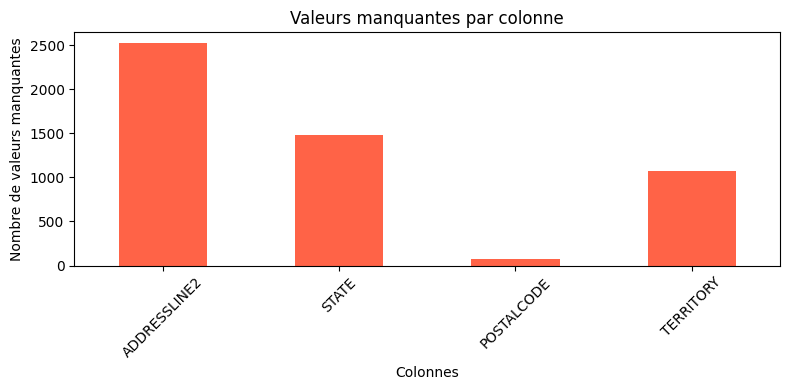

In [34]:
missing = df.isnull().sum()
missing = missing[missing > 0]

plt.figure(figsize=(8, 4))
missing.plot(kind='bar', color='tomato')
plt.title('Valeurs manquantes par colonne')
plt.xlabel('Colonnes')
plt.ylabel('Nombre de valeurs manquantes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../images/missing_values.png')

plt.show()

### Distribution des variables numériques

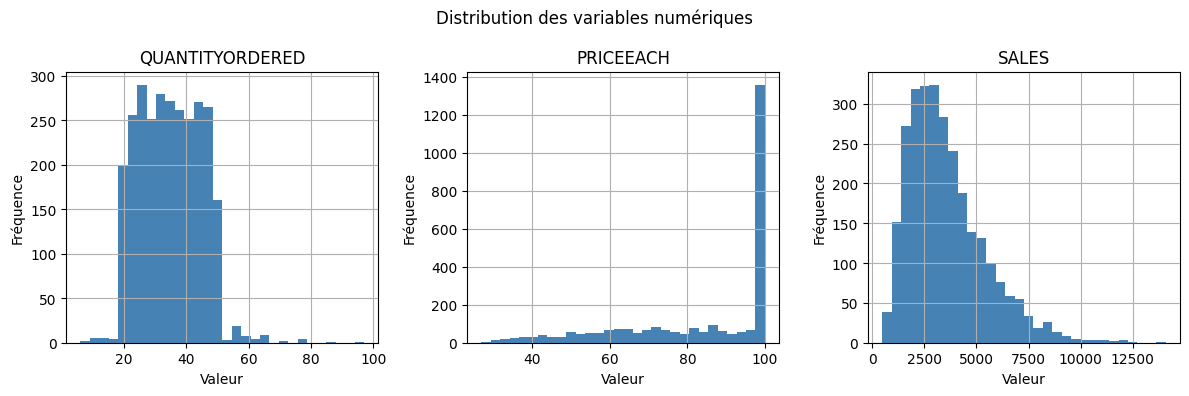

In [35]:
cols = ['QUANTITYORDERED', 'PRICEEACH', 'SALES']

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i, col in enumerate(cols):
    df[col].hist(ax=axes[i], color='steelblue', bins=30)
    axes[i].set_title(col)
    axes[i].set_xlabel('Valeur')
    axes[i].set_ylabel('Fréquence')

plt.suptitle('Distribution des variables numériques')
plt.tight_layout()
plt.savefig('../images/distributions.png')
plt.show()

### Corrélation entre les variables numériques


In [37]:
import seaborn as sns

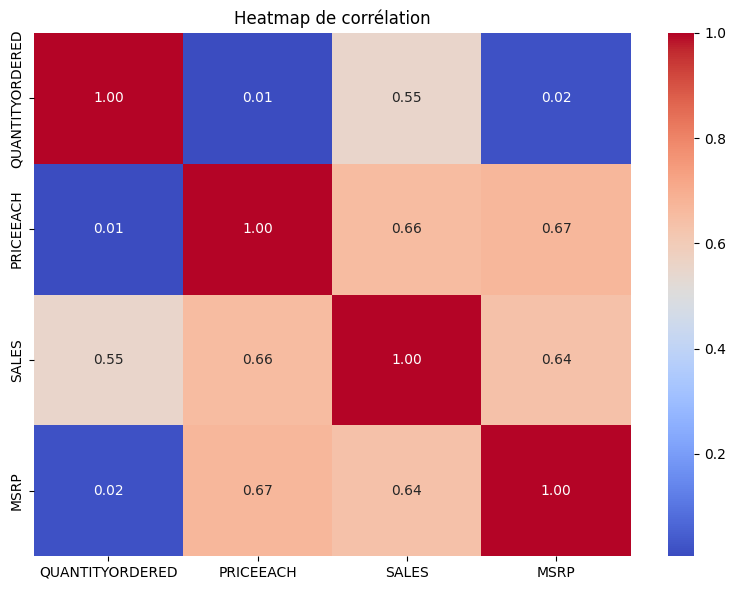

In [38]:
cols_num = ['QUANTITYORDERED', 'PRICEEACH', 'SALES', 'MSRP']

plt.figure(figsize=(8, 6))
sns.heatmap(df[cols_num].corr(), 
            annot=True, 
            cmap='coolwarm', 
            fmt='.2f')
plt.title('Heatmap de corrélation')
plt.tight_layout()
plt.savefig('../images/heatmap.png')
plt.show()

## Partie 2 : Détection des Problèmes de Qualité


### Problème 1 : Valeurs manquantes


In [39]:
missing = df.isnull().sum()
missing = missing[missing > 0]
missing_pct = (missing / len(df) * 100).round(2)

rapport_missing = pd.DataFrame({
    'Valeurs manquantes': missing,
    'Pourcentage (%)': missing_pct
})

print(rapport_missing)

              Valeurs manquantes  Pourcentage (%)
ADDRESSLINE2                2521            89.30
STATE                       1486            52.64
POSTALCODE                    76             2.69
TERRITORY                   1074            38.04


### Problème 2 : Détection des Outliers


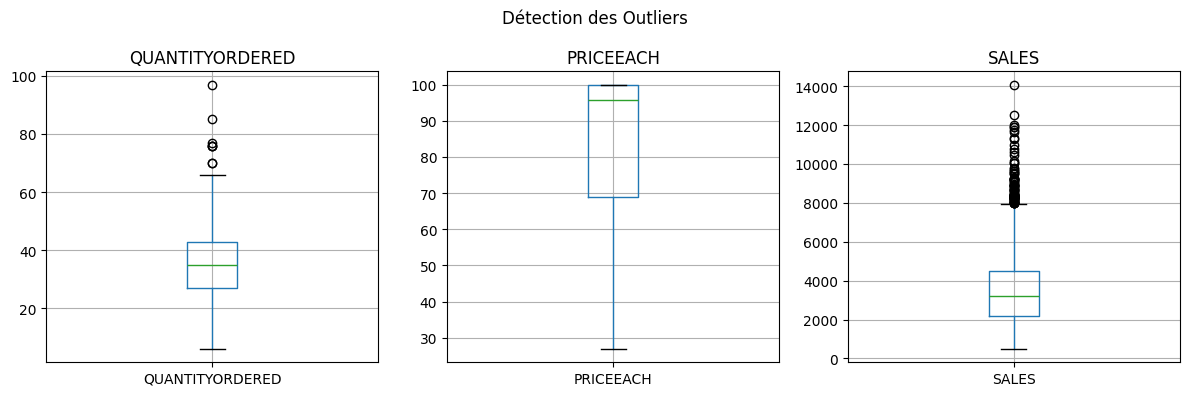

In [40]:
cols = ['QUANTITYORDERED', 'PRICEEACH', 'SALES']

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i, col in enumerate(cols):
    df.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col)

plt.suptitle('Détection des Outliers')
plt.tight_layout()
plt.savefig('../images/outliers.png')
plt.show()

### Problème 3 : Format de date incorrect


In [43]:
print(f"Type actuel de ORDERDATE : {df['ORDERDATE'].dtype}")
print(f"\nExemples de valeurs :")
print(df['ORDERDATE'].head(6))

Type actuel de ORDERDATE : str

Exemples de valeurs :
0     2/24/2003 0:00
1      5/7/2003 0:00
2      7/1/2003 0:00
3     8/25/2003 0:00
4    10/10/2003 0:00
5    10/28/2003 0:00
Name: ORDERDATE, dtype: str


## Partie 3 : Nettoyage & Correction des Données
